# 1. 全体モデルの評価プログラム作成

# 1.1 バッチごとの反事実画像生成プログラム作成

### 1.1.1 プログラムの作成

In [5]:
# metricsのサンプルを取得

import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from dataset.morphomnist import MorphoMNISTLike
from diffusion.utils.utils import resize_images

# Example usage
batch_size = 100
dataset = MorphoMNISTLike(root_dir="/home/hashikami/datadrive/MorphoMNIST",
                            columns=['intensity', 'thickness'], train=False)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

batch = next(iter(data_loader))
print(type(batch))
print(batch['image'].unsqueeze(1).shape)
print(batch['thickness'].shape)

<class 'dict'>
torch.Size([100, 1, 28, 28])
torch.Size([100])


In [3]:

# intensityのインデックスを取得
intensity_idx = list(batch.keys()).index('intensity')
print(f"intensity index: {intensity_idx}")


intensity index: 0


In [ ]:
def scale_image_0_1_to_0_255(image):
    """
    画像の各ピクセル値を0~1スケールから0~255スケールに変換する関数

    Args:
        image (np.ndarray or torch.Tensor): 0~1スケールの画像

    Returns:
        np.ndarray or torch.Tensor: 0~255スケールの画像（同じ型で返す）
    """
    if isinstance(image, torch.Tensor):
        return (image * 255).clamp(0, 255).to(torch.uint8)
    else:
        return np.clip(image * 255, 0, 255).astype(np.uint8)


def produce_counterfactuals(factual_batch: dict, do_parent: str, w: float=0.8):
	
	utils = DiffusionUtils(timesteps=self.config.diffusion.timesteps)
	
	thickness = factual_batch['thickness'][:, None].float()
    intensity = factual_batch['intensity'][:, None].float()
    slant = factual_batch['slant'][:, None].float()
    width = factual_batch['width'][:, None].float()
    x_obs = torch.cat([thickness, intensity, slant, width], dim=1).to(self.device)
    images_obs = factual_batch['image'].unsqueeze(1).to(self.device).float() / 255.0 
    
    cf_idx = [list(factual_batch.keys()).index(do_parent) for _ in range(factual_batch['image'].shape[0])]
    min = float(self.attr_stats[do_parent]['min'])
    max = float(self.attr_stats[do_parent]['max'])
    cf_val = np.random.uniform(min, max, size=factual_batch['image'].shape[0]).tolist()

    # todo: 将来的にはここでoursとcausal vaeを選択できるようにする
    # if model == 'ours':
    noises = utils.ddim_p_sample_loop(self.denoise_model, 0.0, 1, x_obs, w, factual_batch['image'].shape[2], images_obs.shape[0], channels=1, reverse=True, input_img=images_obs)
    x_cf = self.carefl.predict_counterfactual(x_obs, cf_idx, cf_val)
    temp_imgs = utils.ddim_p_sample_loop(self.denoise_model, 0.0, 1, x_cf, w, factual_batch['image'].shape[2], images_obs.shape[0], channels=1, reverse=False, noise=noises[-1])
    cf_images = scale_image_0_1_to_0_255(temp_imgs[-1])
    
    counterfactual_batch = {
    'image': cf_images,
    'thickness': x_cf[:, 0],
    'intensity': x_cf[:, 1],
    'slant': x_cf[:, 2],
    'width': x_cf[:, 3]
    }
        
    # elif model == 'causal vae'
    
    
    return counterfactual_batch
    


### 1.1.2 動作確認

In [28]:
# 準備


import os

os.chdir("/home/hashikami/projects/Diff")

from pathlib import Path
from pipeline.utils import dict2namespace
import yaml


config_path = Path("config/config_all.yaml")
with open(config_path, "r") as f:
    config_raw = yaml.load(f, Loader=yaml.FullLoader)
config = dict2namespace(config_raw)

In [21]:
%load_ext autoreload
%autoreload 2

from pipeline.causal_pipeline import CausalPipeline

pipeline = CausalPipeline(config)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# Morpho-MNISTデータのロード

from dataset.morphomnist import load_morphomnist_like
import numpy as np

dataset_dir = "/home/hashikami/datadrive/morphomnist_all_model"
_, _, metrics_df = load_morphomnist_like(dataset_dir)
metrics = metrics_df.to_numpy().astype(np.float32)

/home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/torchvision/io/image.py:11: UserWarning: Failed to load image Python extension: /home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZNK3c1010TensorImpl36is_contiguous_nondefault_policy_implENS_12MemoryFormatE
  warn(f"Failed to load image Python extension: {e}")


In [5]:
# notearsの適用

from pipeline.causal_pipeline import CausalPipeline


pipeline = CausalPipeline(config)
B_est = pipeline.run_causal_discovery(metrics)
B_est

Running causal discovery for meta-data


/home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/scipy/linalg/_matfuncs.py:378: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw
/home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/scipy/linalg/_matfuncs.py:378: RuntimeWarning: invalid value encountered in matmul
  eAw = eAw @ eAw


array([[0, 1, 1, 0],
       [0, 0, 0, 0],
       [0, 1, 0, 1],
       [0, 0, 0, 0]], dtype=int32)

In [ ]:
import numpy as np

B_true = np.array([
    [0, 1, 1, 1],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0]
])

In [6]:
# careflの訓練

config.carefl.scale_shift_base = True
config.carefl_training.epochs = 30
carefl = pipeline.train_meta_causal_model(metrics, B_true)

Training meta-causal model


100%|██████████| 30/30 [04:50<00:00,  9.69s/it]


In [22]:
# causal_pipeline.pyを修正してリロードした場合
# careflを再学習するのは手間のためpipeline.careflを編集前に学習したもので初期化

pipeline.carefl = carefl

In [24]:
## UNetのロード
import torch
from diffusion.diffusion_model.models.model11 import UNet
from diffusion.utils.utils import load_checkpoint, load_json
import torch.optim  as optim


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
denoise_model = UNet().to(device)
optimizer = optim.Adam(denoise_model.parameters(), lr=1e-3)


# 実験設定ファイルパス
file_path = "/home/hashikami/results/2025-09-30_14/config_20250930.json"
config = load_json(file_path)
epochs = config['epochs']
scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[int(epochs * ratio) for ratio in [0.5, 0.8]],
    gamma=0.2
)


# checkpointの読み込み
checkpoint_path = "/home/hashikami/checkpoint/checkpoint_2025-09-30_15.pth"
denoise_model, optimizer, scheduler, start_epoch, loss = load_checkpoint(denoise_model, optimizer, scheduler, filename=checkpoint_path)
pipeline.denoise_model = denoise_model

In [25]:
from torch.utils.data import DataLoader
from dataset.morphomnist import MorphoMNISTLike


batch_size = 256
testset = MorphoMNISTLike(root_dir="/home/hashikami/datadrive/morphomnist_all_model",
                            columns=['thickness', 'intensity', 'slant', 'width'], train=False)
test_data_loader = DataLoader(testset, batch_size=batch_size, shuffle=True)
one_factual_batch = next(iter(test_data_loader))


MIN_MAX = {
    "thickness": [0.82152224, 6.384839],
    "intensity": [66.48045, 254.93214],
    "slant": [-43.692436, 66.94711],
    "width": [10.000215, 24.999382],
    "image": [0.0, 255.0]
}

do_parent = 'intensity'
min = MIN_MAX[do_parent][0]
max = MIN_MAX[do_parent][1]
intervention_source = np.random.uniform(min, max, size=one_factual_batch['image'].shape[0]).tolist()
counterfactual_batch = pipeline.produce_counterfactuals(one_factual_batch, do_parent, intervention_source, w=0.8)

sampling loop time step: 100%|██████████| 500/500 [00:31<00:00, 15.64it/s]


In [26]:
print(counterfactual_batch['image'].shape, counterfactual_batch['image'].min().item(), counterfactual_batch['image'].max().item())
print(counterfactual_batch['intensity'].shape, counterfactual_batch['intensity'].min().item(), counterfactual_batch['intensity'].max().item())
print(counterfactual_batch['thickness'].shape, counterfactual_batch['thickness'].min().item(), counterfactual_batch['thickness'].max().item())
print(counterfactual_batch['slant'].shape, counterfactual_batch['slant'].min().item(), counterfactual_batch['slant'].max().item())
print(counterfactual_batch['width'].shape, counterfactual_batch['width'].min().item(), counterfactual_batch['width'].max().item())



torch.Size([256, 1, 28, 28]) -1.0 1.0
torch.Size([256]) -0.9943138360977173 0.9900034666061401
torch.Size([256]) -0.8666827082633972 0.22115767002105713
torch.Size([256]) -0.8696550130844116 0.2402111291885376
torch.Size([256]) -0.9997183084487915 0.9646924734115601


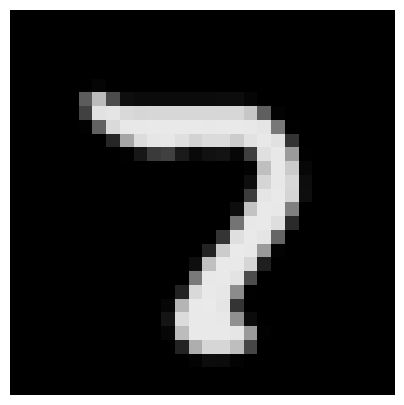

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.imshow(counterfactual_batch['image'][0].squeeze().detach().cpu().numpy(), cmap='gray', vmin=-1, vmax=1)
plt.axis('off')
plt.show()


## 1.2 effectiveness計算プログラム作成

### 1.2.1 画像回帰モデル用MorphoMNISTデータローダの実装と動作確認

In [1]:
from torch.utils.data import DataLoader
from dataset.morphomnist import MorphoMNISTLikeForClassifier

attribute_size = {
        "thickness": 1,
        "intensity": 1,
        "slant": 1,
        "width": 1
    }
batch_size = 64

testset = MorphoMNISTLikeForClassifier(attribute_size=attribute_size, split="train", normalize_=True ,data_dir="/home/hashikami/datadrive/morphomnist_all_model")
test_data_loader = DataLoader(testset, batch_size=batch_size, shuffle=True)
one_batch = next(iter(test_data_loader))
images, attrs = one_batch
print(images.shape)
print(attrs.shape)

/home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/torchvision/io/image.py:11: UserWarning: Failed to load image Python extension: /home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZNK3c1010TensorImpl36is_contiguous_nondefault_policy_implENS_12MemoryFormatE
  warn(f"Failed to load image Python extension: {e}")


torch.Size([64, 1, 28, 28])
torch.Size([64, 4])


### 1.2.2 反因果予測器の実装と動作確認

In [2]:
from evaluate.classifier.classifier import Classifier

attribute = "thickness"
anticausal_graph = {
        "thickness": ["intensity", "slant", "width"],
        "intensity": [],
        "slant": [],
        "width": []
    }
num_outputs = attribute_size[attribute]
context_dim = len(anticausal_graph[attribute])

classifier = Classifier(attr=attribute, width=8, num_outputs=num_outputs,
                                        context_dim=context_dim, lr=1e-3)

In [4]:
import torch


# Check input dimensions
print("Input image shape:", images.shape)  # Should be [batch_size, channels, height, width]

# For thickness classifier, we need context variables (intensity, slant, width)
context = torch.cat([
    attrs[:,1].view(-1,1),  # intensity 
    attrs[:,2].view(-1,1),  # slant
    attrs[:,3].view(-1,1)   # width
], dim=1)
print("Context shape:", context.shape)  # Should be [batch_size, 3]

# Run forward pass to check output
with torch.no_grad():
    output = classifier(images, context)
print("Output shape:", output.shape)  # Should be [batch_size, 1] for thickness prediction


Input image shape: torch.Size([64, 1, 28, 28])
Context shape: torch.Size([64, 3])
Output shape: torch.Size([64, 1])


In [5]:
train_loss = classifier.training_step(one_batch, 0)
print(train_loss)
val_loss = classifier.validation_step(one_batch, 0)
print(val_loss)

tensor(0.1941, grad_fn=<MseLossBackward0>)
tensor(0.1941, grad_fn=<MseLossBackward0>)


/home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/pytorch_lightning/core/module.py:436: You are trying to `self.log()` but the `self.trainer` reference is not registered on the model yet. This is most likely because the model hasn't been passed to the `Trainer`


## 1.3 評価プログラムの修正

### 1.3.1 シミュレーションでの介入値の生成方法

#### 第一四分位数と第三四分位数を用いるケース

In [3]:
def calculate_quartile_ranges(metrics_df, attributes=['thickness', 'intensity', 'slant', 'width']):
    """
    metrics_dfからそれぞれの属性の第一四分位数から第三四分位数の値をリストとして格納する関数
    
    Args:
        metrics_df (pd.DataFrame): thickness, intensity, slant, widthの属性を持つデータフレーム
        attributes (list): 処理する属性のリスト
        
    Returns:
        dict: 各属性の第一四分位数から第三四分位数の値をリストとして格納した辞書
    """
    quartile_ranges = {}
    
    for attr in attributes:
        if attr in metrics_df.columns:
            # 第一四分位数 (25パーセンタイル) と第三四分位数 (75パーセンタイル) を計算
            q1 = metrics_df[attr].quantile(0.25)
            q3 = metrics_df[attr].quantile(0.75)
            quartile_ranges[attr] = [q1, q3]
        else:
            print(f"Warning: '{attr}' column not found in metrics_df")
    
    return quartile_ranges

In [4]:
from dataset.morphomnist import load_morphomnist_like

dataset_dir = "/home/hashikami/datadrive/morphomnist_all_model"
_, _, metrics_df = load_morphomnist_like(dataset_dir)
quartile_ranges = calculate_quartile_ranges(metrics_df)
print(quartile_ranges)

/home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/torchvision/io/image.py:11: UserWarning: Failed to load image Python extension: /home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZNK3c1010TensorImpl36is_contiguous_nondefault_policy_implENS_12MemoryFormatE
  warn(f"Failed to load image Python extension: {e}")


{'thickness': [2.04805145, 2.881358275], 'intensity': [117.097564, 197.4233375], 'slant': [-19.0626455, -2.3332007], 'width': [11.03513725, 19.5581495]}


<Axes: ylabel='Frequency'>

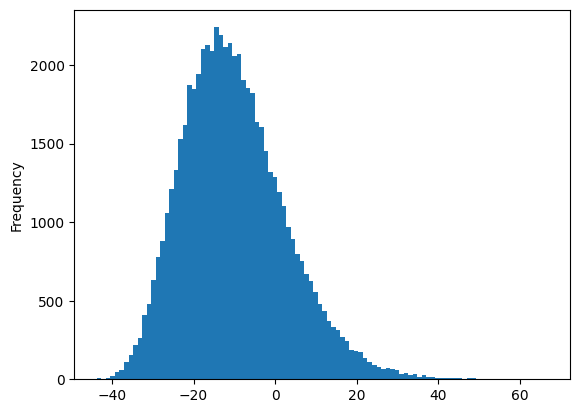

In [4]:
metrics_df['slant'].plot(kind='hist', bins=100)